In [4]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.feature_extraction.text import CountVectorizer

In [5]:
df = pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production br br The filmin...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically theres a family where a little boy J...,negative
4,Petter Matteis Love in the Time of Money is a ...,positive


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49582 entries, 0 to 49581
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     49582 non-null  object
 1   sentiment  49582 non-null  object
dtypes: object(2)
memory usage: 774.8+ KB


DROP DUPLICATE ROWS AND THEN CHECK FOR BALANCED DATASET

In [7]:
df =df.drop_duplicates()

In [8]:
df.groupby('sentiment').describe()

review                                                            \
           count unique                                                top   
sentiment                                                                    
negative   24697  24697  Basically theres a family where a little boy J...   
positive   24884  24884  One of the other reviewers has mentioned that ...   

                
          freq  
sentiment       
negative     1  
positive     1

#### MODEL TRAIN

In [9]:
vector = CountVectorizer(ngram_range=(1,2), stop_words='english', min_df = 10)

x = vector.fit_transform(df['review'])
y = df['sentiment']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.5,random_state=0)



In [10]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, random_state=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

Accuracy: 0.8831027388971804
Confusion Matrix:
 [[10764  1564]
 [ 1334 11129]]


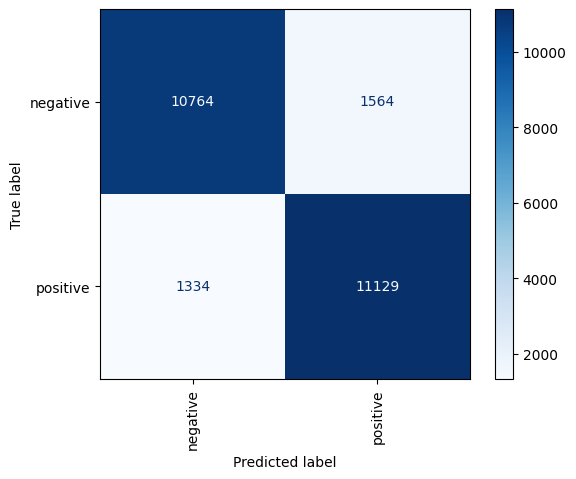

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix ,ConfusionMatrixDisplay as cmd
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

cmd.from_estimator(model,x_test,y_test, display_labels=['negative','positive'],xticks_rotation='vertical',cmap=plt.cm.Blues)

I CAN'T USE RANDOM FOREST OR GARDIENT DESCENT OR OTHER CLASSIFIER BECAUSE THEY ONLY WORK WITH `FLOAT` VALUES

In [12]:
review = 'I AM THE BRAVEST MAN OF EARTH ALIVE AND I WILL KILL U FOR GOD SAKE'
model.predict(vector.transform([review]))


array(['negative'], dtype=object)